# Autism Screening Classification

This notebook is the portfolio-friendly walkthrough for the repository pipeline. It uses the same helper modules as `train.py`.

## 1. Imports

In [1]:
from pathlib import Path
import sys

import pandas as pd
from sklearn.model_selection import train_test_split

ROOT_DIR = Path.cwd()
if ROOT_DIR.name == "notebooks":
    ROOT_DIR = ROOT_DIR.parent

if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

from src.config import (
    DATA_PATH,
    EXPERIMENT_NAME,
    N_ESTIMATORS,
    RANDOM_STATE,
    TARGET_COLUMN,
    TEST_SIZE,
)
from src.data.load_data import load_dataset
from src.evaluation.metrics import evaluate_model
from src.features.preprocessing import build_preprocessor, split_features_target
from src.models.train_model import build_model, build_pipeline, train_pipeline
from src.tracking.mlflow_utils import configure_mlflow, log_training_run

## 2. Config

In [2]:
config_summary = {
    "data_path": str(DATA_PATH),
    "target_column": TARGET_COLUMN,
    "test_size": TEST_SIZE,
    "random_state": RANDOM_STATE,
    "n_estimators": N_ESTIMATORS,
    "experiment_name": EXPERIMENT_NAME,
}

pd.Series(config_summary)

data_path          C:\Users\User\Documents\autismmlops\data\Autis...
target_column                                              Class/ASD
test_size                                                        0.2
random_state                                                      42
n_estimators                                                     100
experiment_name                            autism-screening-baseline
dtype: object

## 3. Data Loading

In [3]:
df = load_dataset(DATA_PATH)
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,relation,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,26.0,f,White-European,no,no,United States,no,6,Self,0
1,1,1,0,1,0,0,0,1,0,1,24.0,m,Latino,no,yes,Brazil,no,5,Self,0
2,1,1,0,1,1,0,1,1,1,1,27.0,m,Latino,yes,yes,Spain,no,8,Parent,1
3,1,1,0,1,0,0,1,1,0,1,35.0,f,White-European,no,yes,United States,no,6,Self,0
4,1,0,0,0,0,0,0,1,0,0,40.0,f,NaN,no,no,Egypt,no,2,NaN,0


## 4. Quick EDA

In [4]:
print("Dataset shape:", df.shape)
print("\nClass balance:")
print(df[TARGET_COLUMN].value_counts(normalize=True).rename("share"))

missing_summary = df.isna().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0]

Dataset shape: (704, 20)

Class balance:
Class/ASD
0    0.731534
1    0.268466
Name: share, dtype: float64


ethnicity    95
relation     95
age           2
dtype: int64

## 5. Preprocessing

In [5]:
X, y = split_features_target(df, target_col=TARGET_COLUMN)
preprocessor = build_preprocessor(X)

numeric_columns = X.select_dtypes(include="number").columns.tolist()
categorical_columns = X.select_dtypes(exclude="number").columns.tolist()

print("Numeric columns:", numeric_columns)
print("Categorical columns:", categorical_columns)

Numeric columns: ['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'result']
Categorical columns: ['gender', 'ethnicity', 'jundice', 'austim', 'contry_of_res', 'used_app_before', 'relation']


## 6. Train/Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (563, 19)
Test shape: (141, 19)


## 7. Model Training

In [7]:
model = build_model(n_estimators=N_ESTIMATORS, random_state=RANDOM_STATE)
pipeline = build_pipeline(preprocessor, model)
trained_pipeline = train_pipeline(pipeline, X_train, y_train)

trained_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['A1_Score','A2_Score','A3_Score',...,'used_app_before','result', 'relation']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``

## 8. Evaluation

In [8]:
metrics = evaluate_model(trained_pipeline, X_test, y_test)
pd.DataFrame([metrics])

,accuracy,precision,recall,f1
0,1.0,1.0,1.0,1.0


## 9. MLflow Logging

In [9]:
tracking_uri = configure_mlflow(EXPERIMENT_NAME)
run_id = log_training_run(
    trained_pipeline,
    params={
        "model_type": "RandomForestClassifier",
        "n_estimators": N_ESTIMATORS,
        "random_state": RANDOM_STATE,
        "test_size": TEST_SIZE,
        "target_column": TARGET_COLUMN,
    },
    metrics=metrics,
)

print("Tracking URI:", tracking_uri)
print("Run ID:", run_id)

2026/06/13 09:56:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/13 09:56:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Tracking URI: file:///C:/Users/User/Documents/autismmlops/mlruns
Run ID: 7258bbe96a4543a097248a7dff51348e


## 10. Baseline Comparison and Dataset Limits

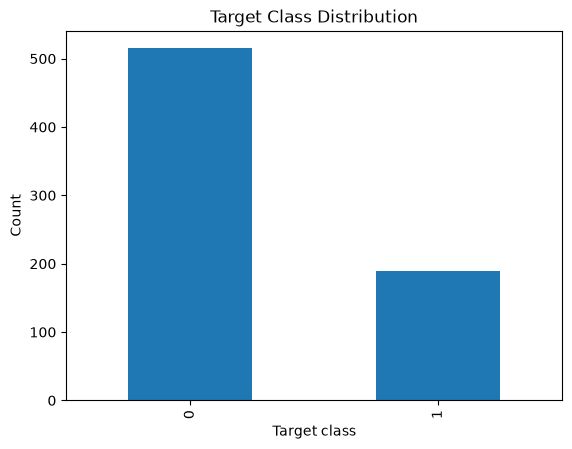

In [10]:
import matplotlib.pyplot as plt

target_counts = df[TARGET_COLUMN].value_counts()

target_counts.plot(kind="bar")
plt.title("Target Class Distribution")
plt.xlabel("Target class")
plt.ylabel("Count")
plt.show()

In [16]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")

dummy.fit(X_train,y_train)

metrics_dummy = evaluate_model(dummy, X_test, y_test)

pd.DataFrame({
    "Model": ["RandomForest","DummyClassifier"],
    "Accuracy":[metrics["accuracy"],metrics_dummy["accuracy"]],
    "precision":[metrics["precision"],metrics_dummy["precision"]],
    "recall":[metrics["recall"],metrics_dummy["recall"]],
    "f1":[metrics["f1"],metrics_dummy["f1"]]
})

,Model,Accuracy,precision,recall,f1
0,RandomForest,1.000000,1.0,1.0,1.0
1,DummyClassifier,0.730496,0.0,0.0,0.0


The Random Forest model achieved perfect scores across all evaluation metrics, but this result should be interpreted carefully. The DummyClassifier, which only predicts the majority class, performed much worse, suggesting that the Random Forest is not simply benefiting from class imbalance and is likely using meaningful signals from the features. However, near-perfect performance does not guarantee real-world robustness; the dataset may be easy, limited in diversity, or contain very strong signals that may not generalize well outside this dataset.

## 11. Next Steps

- Add feature importance analysis for model interpretation.
- Add lightweight unit tests for each helper module.
- Optionally connect DagsHub credentials to send MLflow runs to a remote tracker.